In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv(r'C:\Users\LPP\Desktop\grok\Netflix Project\my movie db.csv', 
                 engine='python')

In [43]:
df.head(10)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,2022-01-07,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,2022-01-12,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,2022-02-10,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,2022-02-17,Fistful of Vengeance,A revenge mission becomes a fight to save the ...,1594.013,114,5.3,en,"Action, Crime, Fantasy",https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,2021-11-03,Eternals,The Eternals are a team of ancient aliens who ...,1537.406,4726,7.2,en,Science Fiction,https://image.tmdb.org/t/p/original/zByhtBvX99...


In [44]:
df.tail(10)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9827,2005-05-18,I'm in Love With My Little Sister,Yori and his twin sister Iku used to be very c...,13.360,9,5.7,ja,"Romance, Animation, Drama",https://image.tmdb.org/t/p/original/fRdxgR85XX...
9828,2013-08-23,All Is Lost,"During a solo voyage in the Indian Ocean, a ve...",13.359,1319,6.6,en,"Action, Adventure, Drama",https://image.tmdb.org/t/p/original/9cVA4oX2xH...
9829,2008-05-13,Amateur Porn Star Killer 2,Shane Ryan's sequel to the disturbing Amateur ...,13.359,14,5.4,en,"Crime, Horror",https://image.tmdb.org/t/p/original/iBmngXVhDu...
9830,1992-06-26,Unlawful Entry,"After a break-in at their house, a couple gets...",13.358,199,6.1,en,"Crime, Thriller, Mystery",https://image.tmdb.org/t/p/original/sKUk1ca6gH...
9831,1974-11-06,The Little Prince,"Based on the story by Antoine deSaint-Exupery,...",13.357,89,6.6,en,"Science Fiction, Fantasy, Family, Music",https://image.tmdb.org/t/p/original/ts0TGlxlBf...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


In [45]:
# info about columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


***Exploration Summary***

• we have a dataframe consisting of 9827 rows and 9 columns.

• our dataset looks a bit tidy with no_Nulls nor duplicated values.

• Release_Date colum needs to be casted into date time and to extract only the year value.

• Overview, Original_Language and Poster_Url wouldn't be so useful during analysis, so we'll drop them.

• there is noticable outliers in Popularity column

• Vote_Average bettter be categorised for proper analysis.

• Genre colum has comma seperated values and white spaces that needs to be handled and casted into category.

In [46]:
df = df.drop_duplicates()

In [47]:
# to check NUll values
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [48]:
#to drop null values from all columns
df = df.dropna()

df.isna().sum()


Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [49]:
#check genre type
df["Genre"]

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9832                          Drama, Crime
9833                                Horror
9834             Mystery, Thriller, Horror
9835                 Music, Drama, History
9836           War, Drama, Science Fiction
Name: Genre, Length: 9826, dtype: object

In [50]:
#to chenge data type

df["Vote_Count"] = df["Vote_Count"].astype(int)

In [51]:
#to chenge data type

df["Vote_Average"] = df["Vote_Average"].astype(float)

In [52]:
# duplicate values

df.duplicated().sum()

np.int64(0)

In [53]:
# to check basic statistics

df.describe()

,Popularity,Vote_Count,Vote_Average
count,9826.000000,9826.000000,9826.000000
mean,40.323951,1392.943721,6.439467
std,108.879332,2611.303856,1.129797
min,13.354000,0.000000,0.000000
25%,16.128250,146.000000,5.900000
50%,21.195000,444.000000,6.500000
75%,35.179250,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [54]:
#["Release_Date"] (object) convert to datetime

df["Release_Date"] = pd.to_datetime(df["Release_Date"])

print(df["Release_Date"].dtypes)

datetime64[ns]


In [55]:
df["Release_Date"] = df["Release_Date"].dt.year

df["Release_Date"].dtypes

dtype('int32')

In [56]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


***to drop unwanted columns***

In [57]:
cols = ["Overview","Original_Language","Poster_Url"]

In [58]:
df.drop(cols, axis = 1 , inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [59]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


***categorizing Vote_Average column***

We would cut the ***Vote_Average*** values and make 4 categories: ***popular average*** ***,*** ***below_avg*** ***not_popular*** to describe it more using catigorize_col() function provided above.

In [60]:
def categorize_col(df, col, labels):
    
    edges = [df[col].describe()["min"],
            df[col].describe()["25%"],
            df[col].describe()["50%"],
            df[col].describe()["75%"],
            df[col].describe()["max"]]
    
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates="drop")
    return df

In [61]:
labels = ["not_popular","below_avg","average","popular"]

categorize_col(df,"Vote_Average",labels)

df["Vote_Average"].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [62]:
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [63]:
df["Vote_Average"].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

***we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie***

In [64]:
#to adjust genre alighnment

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [65]:
df["Genre"] = df["Genre"].str.split(", ")

df = df.explode("Genre").reset_index(drop = True)

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [76]:
df.tail()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


In [67]:
# casting columns into category

df["Genre"] = df["Genre"].astype("category")

df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [68]:
#to check the info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  int32   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25792 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.6+ KB


In [80]:
#to check unique

df.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

In [70]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


***Data Visualization***

In [71]:
sns.set_style("whitegrid")

# 1.What is the most frequent genre of movies released on Netflix?

In [72]:
#basic Idea
df["Genre"].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

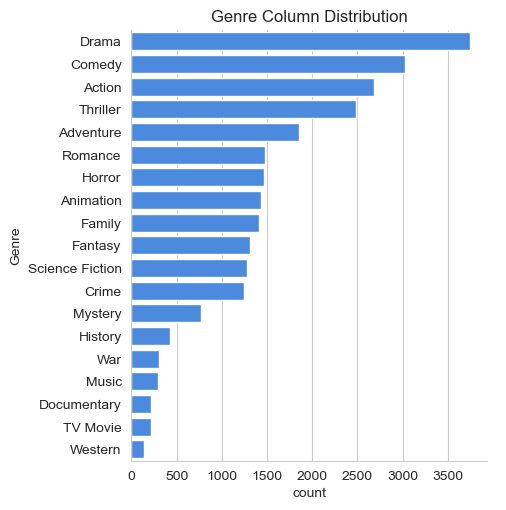

In [81]:
sns.catplot( y = "Genre" , data=df , kind = "count" , 
             order = df["Genre"].value_counts().index,
             color = "#3487f5")

plt.title("Genre Column Distribution")
plt.show()

# 2.Which has highest votes in vote avg column?

In [100]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


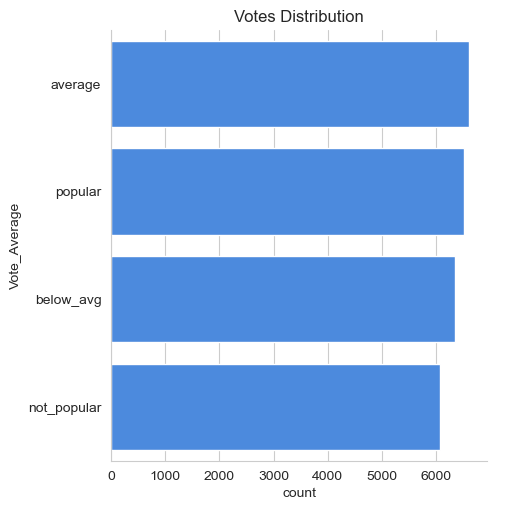

In [83]:
sns.catplot( y="Vote_Average" , data=df , kind = "count" ,
             order = df["Vote_Average"].value_counts().index,
             color = "#3487f5")
plt.title("Votes Distribution")

plt.show()


# 3.what movie got the highest popuplarity? what's it's genre?

In [90]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [92]:
df[df["Popularity"] == df["Popularity"].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


# 4.what movie got the lowest popularity

In [99]:
df[df["Popularity"] == df["Popularity"].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


# 5.Which year has the most filmmed movies?

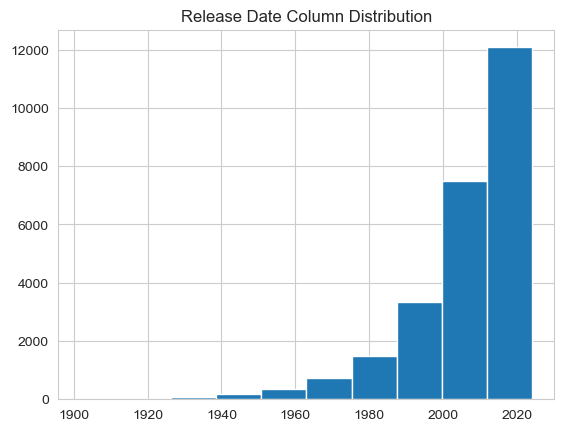

In [108]:
df["Release_Date"].hist()
plt.title("Release Date Column Distribution")
plt.show()


# Conclusion


__Q1: What is the most frequent genre in the dataset?__

   _Drama genre is the most frequent genre in our dataset and has appeared more than
   14% of the times among 19 other genres._
    
__Q2: What genres has highest votes ?__

   _we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the
   highest popularity among fans by being having more than 18.5% of movies popularities._

__Q3: What movie got the highest popularity ? what's its genre ?__

   _Spider-Man: No Way Home has the highest popularity rate in our dataset and it has
   genres of Action , Adventure and Sience Fiction._

__Q3: What movie got the lowest popularity ? what's its genre ?__
    
 _The united states, thread' has the highest lowest rate in our dataset
    and it has genres of music , drama , 'war', 'sci-fi' and history`._

__Q4: Which year has the most filmmed movies?__

   _year 2020 has the highest filmming rate in our dataset_